# DCT Basis Benchmarks for Neural Image Compression

This notebook demonstrates the core DCT benchmark pipeline: how to evaluate any image codec's **frequency response** using DCT basis matrices as diagnostic inputs.

### What this benchmark reveals

Traditional image quality metrics (PSNR, MS-SSIM) summarize **overall** reconstruction fidelity but hide *which frequency components* a codec distorts. By compressing an $n\times n$ DCT basis matrix, where spatial position uniquely encodes a frequency pair, we obtain a **per-frequency leakage profile** that exposes codec biases invisible to pixel-level metrics.

### Pipeline

```
DCT basis D = DCT(Iₙ)  →  [Codec]  →  D̂  →  R = DCT-domain response  →  L_k, ODR, Δc, σ, H
```

### Key metrics

| Metric | Symbol | Interpretation |
|--------|--------|----------------|
| **Leakage** | $L_k = 1 - R_{k,k}$ | Energy lost from frequency $k$ ↓ better |
| **Off-Diagonal Ratio** | $\text{ODR}_k$ | Energy redistributed to other bands ↓ better |
| **Centroid Shift** | $\|\Delta_k\|$ | Systematic drift of energy centroid ↓ better |
| **Spread** | $\sigma_k$ | Broadening of response around target ↓ better |
| **Entropy** | $H_k$ | Indiscriminate energy redistribution ↓ better |

---

**Reference:** Kalmykov et al., *DCT Basis Benchmarks for Neural Image Compression*.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from PIL import Image, ImageFile

from dct_nic import evaluate_codec, load_model, build_dct_basis, build_dct_basis_rgb

%config InlineBackend.figure_format = "retina"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RESULTS = Path("../results")
print(f"Device: {DEVICE}")

Device: cuda


## 1. DCT Basis Matrix

The $n\times n$ DCT basis matrix $D = \text{DCT}(I_n)$ is the diagnostic input. Each column $d_k$ is a spatial-domain image of the $k$-th DCT basis vector. When arranged as a 2D image, the top-left encodes low frequencies and the bottom-right encodes high frequencies.

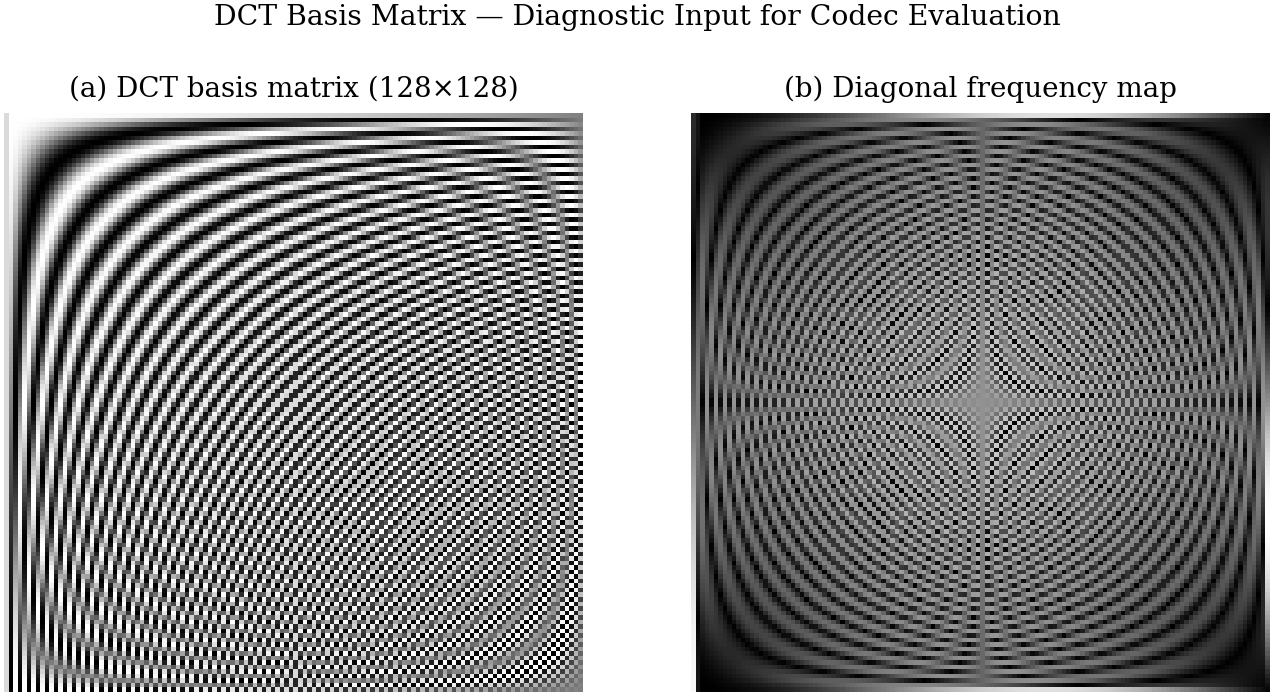

D shape: (128, 128),  range: [-0.125, 0.125]
Top-left = low frequencies, bottom-right = high frequencies
Panel (c) - codec reconstruction - is shown after model evaluation below.


In [18]:
SIZE = 128

D = build_dct_basis(SIZE)
D_rgb, vmin, vmax = build_dct_basis_rgb(SIZE)

# Diagonal-direction frequency map (gradient magnitude of DCT basis).
# Matches Fig. 1(b) in the paper: dark = low frequency, bright = high frequency.
gy, gx = np.gradient(D)
freq_map = np.hypot(gx, gy)
freq_map = (freq_map - freq_map.min()) / (freq_map.max() - freq_map.min() + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(D_rgb.mean(axis=2), cmap='gray')
axes[0].set_title(f'(a) DCT basis matrix ({SIZE}×{SIZE})')
axes[0].axis('off')

axes[1].imshow(freq_map, cmap='gray')
axes[1].set_title('(b) Diagonal frequency map')
axes[1].axis('off')

plt.suptitle('DCT Basis Matrix — Diagnostic Input for Codec Evaluation', y=1.02)
plt.tight_layout()
plt.show()

print(f'D shape: {D.shape},  range: [{D.min():.3f}, {D.max():.3f}]')
print('Top-left = low frequencies, bottom-right = high frequencies')
print('Panel (c) - codec reconstruction - is shown after model evaluation below.')

## 2. Evaluate a Single Codec

Compress the DCT basis, recover the frequency-response matrix $R$, and compute all metrics.

**Custom model interface:** any callable `f(x) → {"x_hat": tensor}` works.

In [3]:
# Load a model - replace with your own model to test leakage
model = load_model('cheng2020-anchor', quality=6, device=DEVICE)

# Run evaluation
result = evaluate_codec(model, size=SIZE, device=DEVICE, model_name='cheng2020-anchor', num_runs=1)

print(f"Median leakage  L_k      = {result['L_k']:.4f}")
print(f"Low-band leakage L_low   = {result['L_low']:.4f}")
print(f"High-band leakage L_high = {result['L_high']:.4f}")
print(f"Median ODR_k             = {result['ODR_k']:.4f}")
print(f"Median |Δc_k|            = {result['|Δc_k|']:.4f}")
print(f"Median spread σ_k        = {result['s_k']:.4f}")
print(f"Median entropy H_k       = {result['H_k']:.4f}")
print(f"Bitrate                  = {result['bpp']:.3f} bpp" if result['bpp'] else 'Bitrate: N/A')

Median leakage  L_k      = 0.2871
Low-band leakage L_low   = 0.0775
High-band leakage L_high = 0.6064
Median ODR_k             = 0.1987
Median |Δc_k|            = 0.0193
Median spread σ_k        = 0.1474
Median entropy H_k       = 0.2858
Bitrate                  = 2.531 bpp


## 3. Frequency-Response Matrix and Metrics

The $R$ matrix: column $k$ shows where energy from input frequency $k$ ends up after compression. The ideal case is $R = I$ (identity). Deviations reveal codec biases.

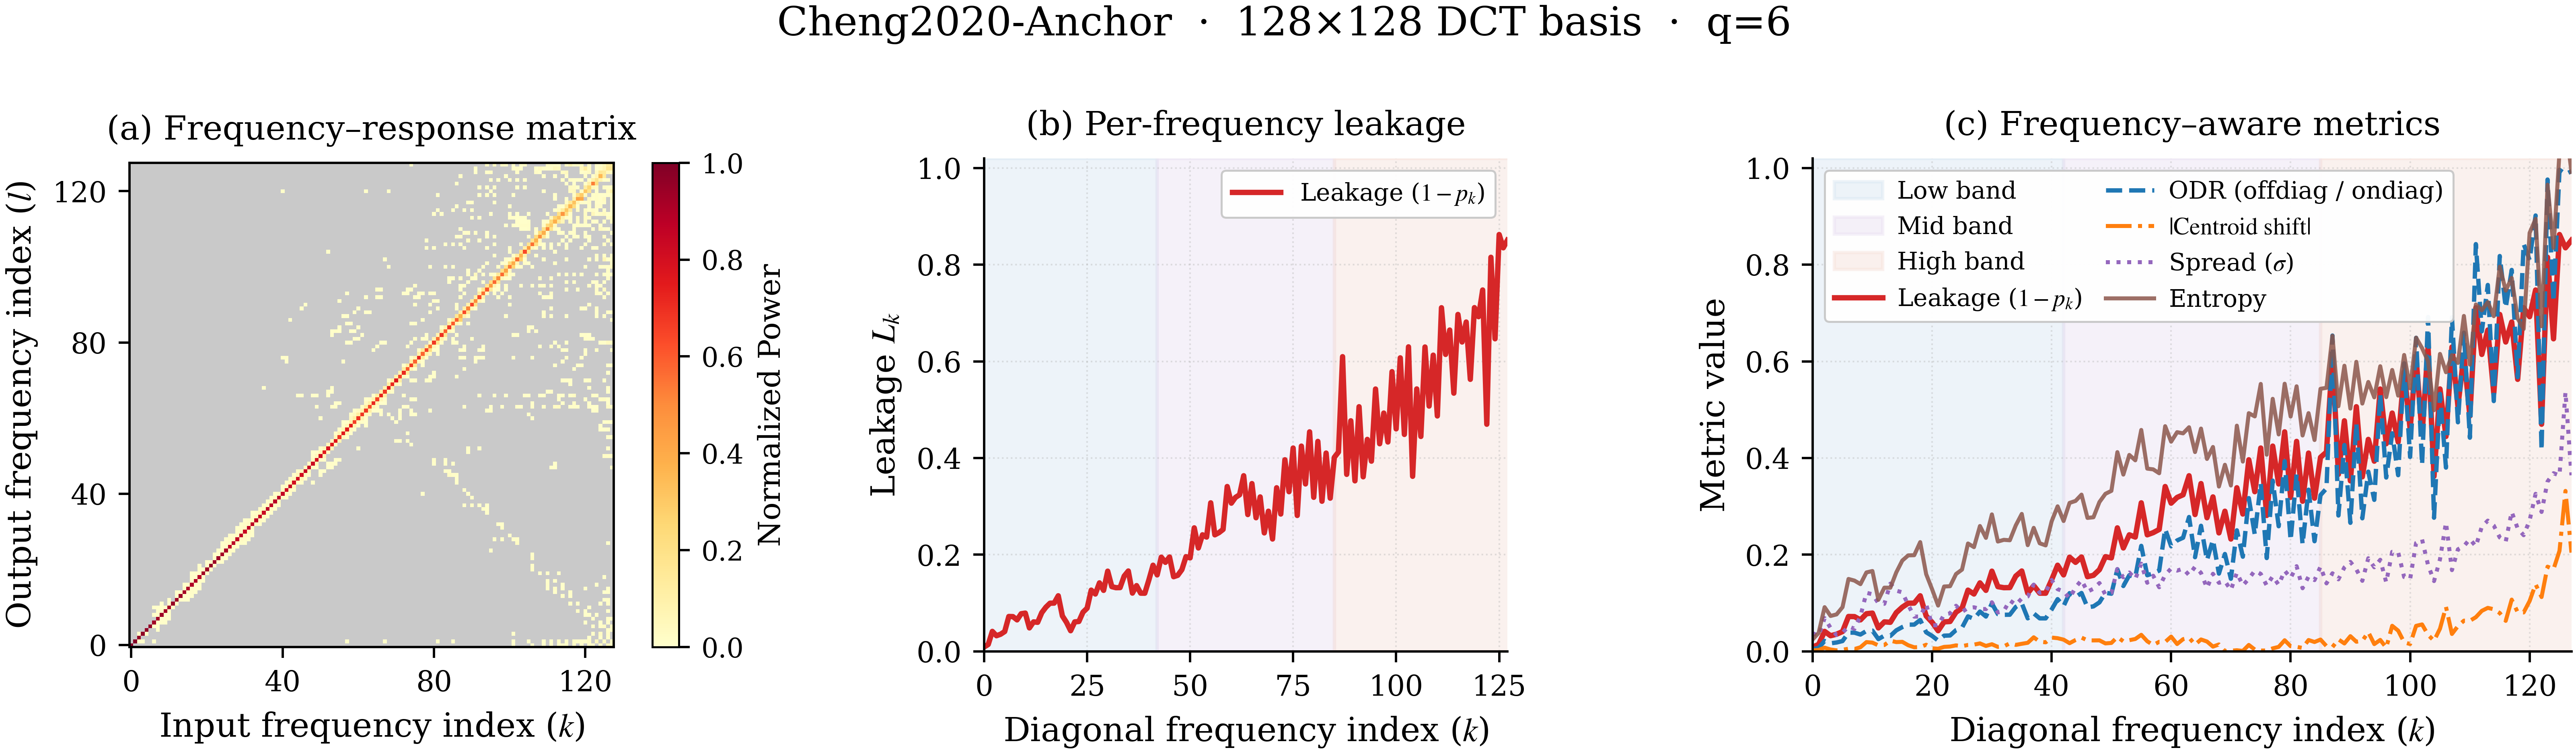

In [17]:
# Paper-style matplotlib
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 8.5,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 7.2,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "axes.linewidth": 0.7,
    "lines.linewidth": 1.3,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3.2,
    "ytick.major.size": 3.2,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})


def style_axis(ax, grid=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid:
        ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.35)
    ax.tick_params(direction="out")


def add_band_background(ax, size, low_c, mid_c, high_c, alpha=0.42):
    b1 = size // 3
    b2 = 2 * size // 3
    ax.axvspan(0, b1, color=low_c, alpha=alpha, zorder=0)
    ax.axvspan(b1, b2, color=mid_c, alpha=alpha, zorder=0)
    ax.axvspan(b2, size, color=high_c, alpha=alpha, zorder=0)


# Inputs
R = result["R"]
leakage = np.asarray(result["leakage"])
odr = np.asarray(result["odr"])
centroid_shift = np.abs(np.asarray(result["centroid_shift"]))
spread = np.asarray(result["spread"])
entropy = np.asarray(result["entropy"]) / np.log(2)
k = np.arange(SIZE)

# band colors
low_c  = "#D9E6F2"
mid_c  = "#E9E0F2"
high_c = "#F6E1DA"

# Figure layout
fig = plt.figure(figsize=(11.0, 3.35), dpi=300, constrained_layout=False)
gs = gridspec.GridSpec(
    1, 3, figure=fig,
    width_ratios=[1.05, 1.0, 1.45],
    wspace=0.50
)

# (a) Frequency-response matrix
ax0 = fig.add_subplot(gs[0])

threshold = 0.005
R_masked = np.ma.masked_less(R, threshold)

cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color="#C9C9C9")

im = ax0.imshow(
    R_masked,
    origin="lower",
    cmap=cmap,
    vmin=0,
    vmax=1,
    interpolation="nearest",
    aspect="equal"
)

ax0.set_xlim(-0.5, SIZE - 0.5)
ax0.set_ylim(-0.5, SIZE - 0.5)
ax0.set_xlabel(r"Input frequency index ($k$)")
ax0.set_ylabel(r"Output frequency index ($l$)")
ticks = np.arange(0, SIZE + 1, 40)
ax0.set_xticks(ticks)
ax0.set_yticks(ticks)
ax0.set_title(r"(a) Frequency–response matrix", pad=7)
ax0.grid(False)

divider = make_axes_locatable(ax0)
cax = divider.append_axes("right", size="5.5%", pad=0.16)
cb = fig.colorbar(im, cax=cax)
cb.set_label("Normalized Power", fontsize=9)
cb.ax.tick_params(labelsize=8)
cb.outline.set_linewidth(0.6)

# (b) Per-frequency leakage
ax1 = fig.add_subplot(gs[1])
add_band_background(ax1, SIZE, low_c, mid_c, high_c, alpha=0.45)

ax1.plot(
    k, leakage,
    color="#D62728",
    lw=1.6,
    label=r"Leakage ($1 - p_k$)"
)

ax1.set_xlim(0, SIZE - 1)
ax1.set_ylim(0, 1.02)
ax1.set_xlabel(r"Diagonal frequency index ($k$)")
ax1.set_ylabel(r"Leakage $L_k$")
ax1.set_title(r"(b) Per-frequency leakage", pad=7)
style_axis(ax1, grid=True)

leg1 = ax1.legend(
    loc="upper right",
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    edgecolor="#C8C8C8",
    borderpad=0.45,
    handlelength=2.0
)
leg1.get_frame().set_linewidth(0.6)

# (c) Frequency-aware metrics
ax2 = fig.add_subplot(gs[2])
add_band_background(ax2, SIZE, low_c, mid_c, high_c, alpha=0.45)

line1, = ax2.plot(
    k, leakage,
    color="#D62728", lw=1.6, ls="-",
    label=r"Leakage ($1 - p_k$)"
)
line2, = ax2.plot(
    k, odr,
    color="#1F77B4", lw=1.3, ls="--",
    label=r"ODR (offdiag / ondiag)"
)
line3, = ax2.plot(
    k, centroid_shift,
    color="#FF7F0E", lw=1.2, ls="-.",
    label=r"$|\mathrm{Centroid\ shift}|$"
)
line4, = ax2.plot(
    k, spread,
    color="#9467BD", lw=1.2, ls=":",
    label=r"Spread ($\sigma$)"
)
line5, = ax2.plot(
    k, entropy,
    color="#8C564B", lw=1.2, ls="-", alpha=0.85,
    label="Entropy"
)

ax2.set_xlim(0, SIZE - 1)
ax2.set_ylim(0, 1.02)
ax2.set_xlabel(r"Diagonal frequency index ($k$)")
ax2.set_ylabel("Metric value")
ax2.set_title(r"(c) Frequency–aware metrics", pad=7)
style_axis(ax2, grid=True)

band_patches = [
    mpatches.Patch(color=low_c,  alpha=0.45, label="Low band"),
    mpatches.Patch(color=mid_c,  alpha=0.45, label="Mid band"),
    mpatches.Patch(color=high_c, alpha=0.45, label="High band"),
]

handles = band_patches + [line1, line2, line3, line4, line5]
labels = [h.get_label() for h in handles]

leg2 = ax2.legend(
    handles, labels,
    loc="upper left",
    ncol=2,
    frameon=True,
    fancybox=True,
    framealpha=0.96,
    edgecolor="#C8C8C8",
    borderpad=0.40,
    columnspacing=1.0,
    handlelength=2.0,
    handletextpad=0.6
)
leg2.get_frame().set_linewidth(0.6)

fig.suptitle(
    "Cheng2020-Anchor  ·  128×128 DCT basis  ·  q=6",
    fontsize=12,
    y=0.99
)

fig.subplots_adjust(
    left=0.065,
    right=0.985,
    bottom=0.19,
    top=0.80,
    wspace=0.52
)

plt.show()

## 4. Compare Original vs Reconstructed

Visually confirm: low-frequency content (top-left) is well preserved; high-frequency content (bottom-right) is strongly attenuated.

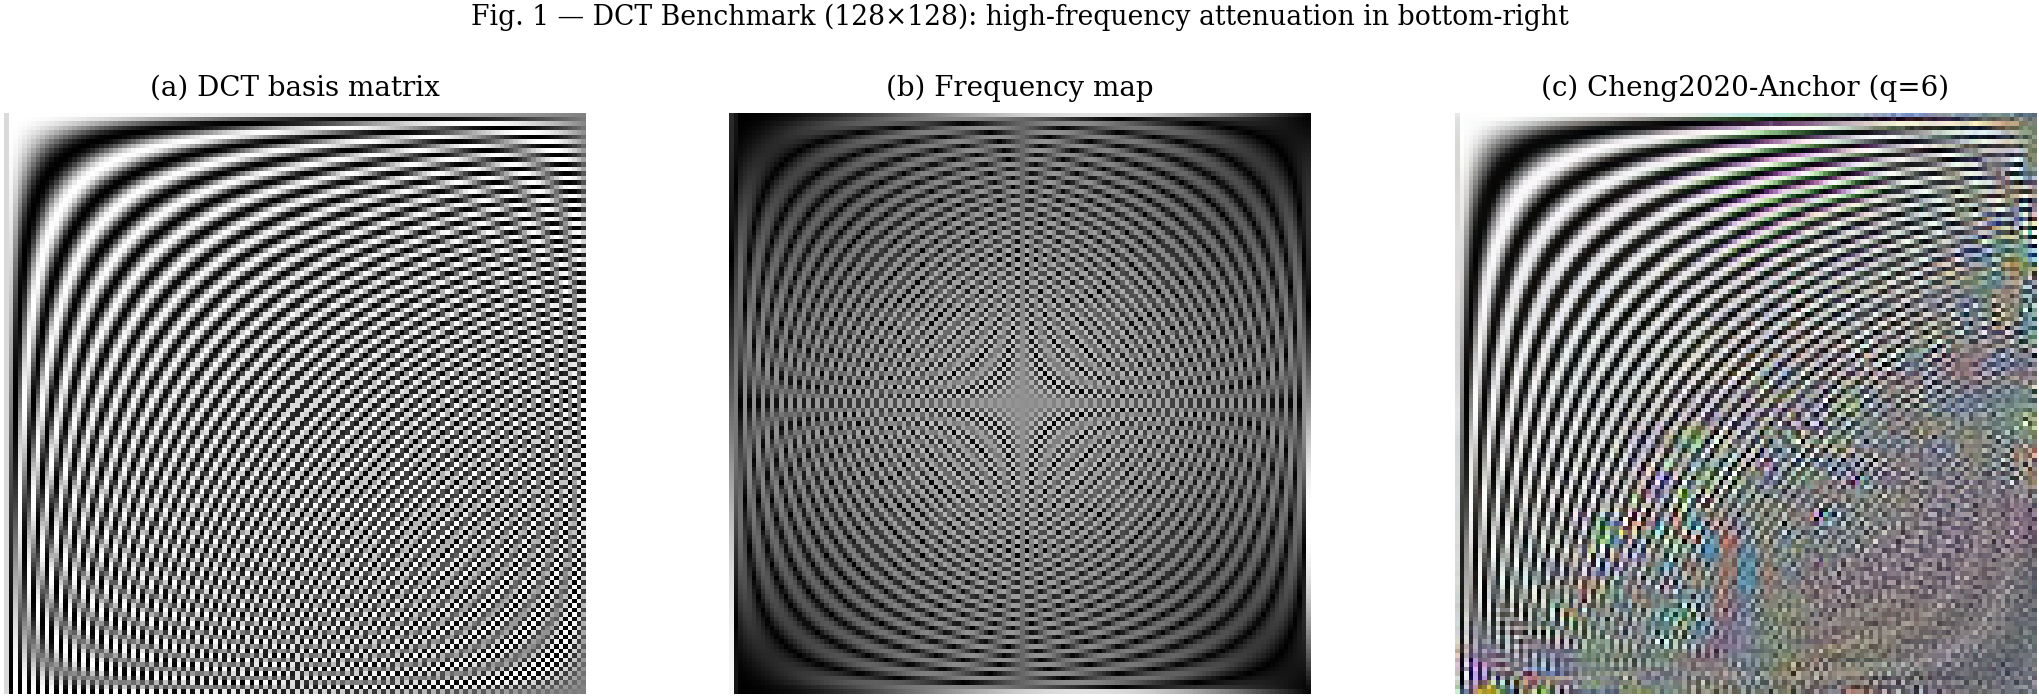

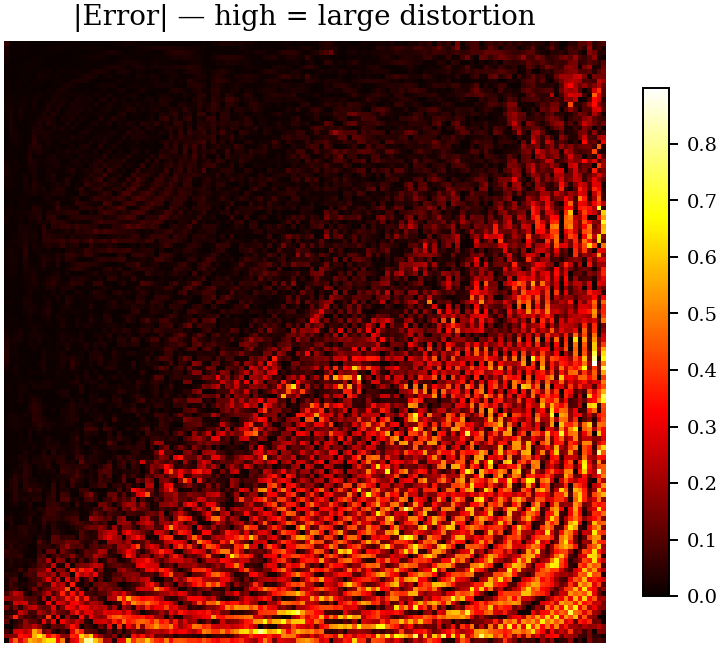

In [16]:
orig = result['orig']    # (n, n, 3) normalized to [0,1]
recon = result['recon']  # (n, n, 3) in original DCT range

_, vmin, vmax = build_dct_basis_rgb(SIZE)
recon_disp = np.clip((recon - vmin) / (vmax - vmin + 1e-9), 0, 1)

# Frequency map (gradient magnitude, same as Fig. 1(b) in the paper)
D = build_dct_basis(SIZE)
gy, gx = np.gradient(D)
freq_map = np.hypot(gx, gy)
freq_map = (freq_map - freq_map.min()) / (freq_map.max() - freq_map.min() + 1e-9)

# Fig. 1 layout from the paper
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))

axes[0].imshow(orig.mean(axis=2), cmap='gray')
axes[0].set_title('(a) DCT basis matrix')
axes[0].axis('off')

axes[1].imshow(freq_map, cmap='gray')
axes[1].set_title('(b) Frequency map')
axes[1].axis('off')

axes[2].imshow(recon_disp)
axes[2].set_title('(c) Cheng2020-Anchor (q=6)')
axes[2].axis('off')

plt.suptitle(
    f"Fig. 1 — DCT Benchmark ({SIZE}×{SIZE}): "
    "high-frequency attenuation in bottom-right",
    y=1.02,
)
plt.tight_layout()
plt.show()

# Error map (additional)
fig2, ax2 = plt.subplots(figsize=(4, 3.5))
diff = np.abs(orig.mean(axis=2) - recon_disp.mean(axis=2))
im = ax2.imshow(diff, cmap='hot', vmin=0)
plt.colorbar(im, ax=ax2, shrink=0.8)
ax2.set_title('|Error| — high = large distortion')
ax2.axis('off')
plt.tight_layout()
plt.show()

## 5. Evaluating Your Own Model

Any model following the interface `model(x) → {"x_hat": tensor}` can be evaluated:

In [8]:
# Example: evaluate a custom / identity model
class IdentityCodec:
    """Lossless passthrough — should give L_k ≈ 0."""
    def __call__(self, x):
        return {"x_hat": x}

res_id = evaluate_codec(IdentityCodec(), size=64, device='cpu')
print(f"Identity codec — median L_k: {res_id['L_k']:.6f}  (expected ≈ 0)")

# Template for your own NIC model:
#
#   import torch
#   from dct_nic import evaluate_codec
#
#   class MyNIC(torch.nn.Module):
#       def forward(self, x):            # x: [1, 3, H, W] in [0, 1]
#           ...                          # your encode–decode here
#           return {"x_hat": x_hat}      # x_hat: same shape
#
#   model = MyNIC().eval()
#   result = evaluate_codec(model, size=256, device='cuda')
#   print(f"Leakage: {result['L_k']:.4f}")

Identity codec — median L_k: 0.000000  (expected ≈ 0)


## 6. Rate-Leakage Curves (Pre-computed Results)

Fig. 5 from the paper: median leakage $L_k$ vs bitrate for all codecs at $256\times256$.
Traditional codecs (dashed) achieve orders-of-magnitude lower leakage than NIC models across all bitrates.

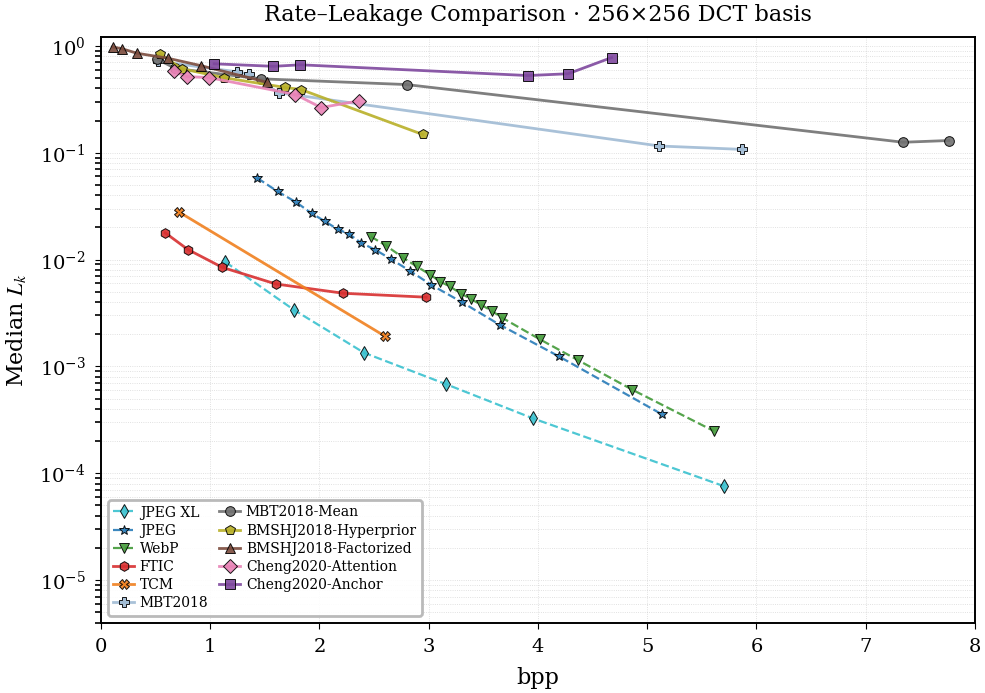

In [ ]:
csv_path = RESULTS / "leakage_vs_bpp" / "scan_leakage_vs_bpp_256.csv"
df = pd.read_csv(csv_path).drop_duplicates(subset=["model", "bpp"])

MODEL_COLORS = {
    "cheng2020-anchor": "#7E489E",
    "cheng2020-attn": "#E883B6",
    "mbt2018-mean": "#717171",
    "mbt2018": "#A0BBD4",
    "bmshj2018-hyperprior": "#B8B028",
    "bmshj2018-factorized": "#7B4B3D",
    "ftic": "#D82F30",
    "tcm": "#F0801F",
    "jpeg": "#287BB8",
    "webp": "#429A38",
    "jpegxl": "#3AC1CF",
}

MODEL_MARKERS = {
    "cheng2020-anchor": "s",
    "cheng2020-attn": "D",
    "mbt2018-mean": "o",
    "mbt2018": "P",
    "bmshj2018-hyperprior": "p",
    "bmshj2018-factorized": "^",
    "ftic": "h",
    "tcm": "X",
    "jpeg": "*",
    "webp": "v",
    "jpegxl": "d",
}

LABEL_TEXT = {
    "bmshj2018-factorized": "BMSHJ2018-Factorized",
    "bmshj2018-hyperprior": "BMSHJ2018-Hyperprior",
    "mbt2018-mean": "MBT2018-Mean",
    "mbt2018": "MBT2018",
    "cheng2020-anchor": "Cheng2020-Anchor",
    "cheng2020-attn": "Cheng2020-Attention",
    "tcm": "TCM",
    "ftic": "FTIC",
    "jpeg": "JPEG",
    "jpegxl": "JPEG XL",
    "webp": "WebP",
}

LINESTYLES = {
    "jpeg": "--",
    "webp": "--",
    "jpegxl": "--",
}

PLOT_ORDER_ALL = [
    "jpegxl",
    "jpeg",
    "webp",
    "ftic",
    "tcm",
    "mbt2018",
    "mbt2018-mean",
    "bmshj2018-hyperprior",
    "bmshj2018-factorized",
    "cheng2020-attn",
    "cheng2020-anchor",
]

order = [m for m in PLOT_ORDER_ALL if m in df["model"].unique()]

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

fig, ax = plt.subplots(figsize=(5.0, 3.5))

for name in order:
    sub = df[df["model"] == name].sort_values("bpp")
    if sub.empty:
        continue

    bpp = sub["bpp"].values
    lk = sub["L_k"].values

    color = MODEL_COLORS.get(name, "gray")
    marker = MODEL_MARKERS.get(name, "o")
    ls = LINESTYLES.get(name, "-")
    lw = 0.8 if ls == "--" else 1.0

    ax.plot(
        bpp,
        lk,
        ls,
        color=color,
        marker=marker,
        markersize=3.5,
        markeredgecolor="black",
        markeredgewidth=0.35,
        linewidth=lw,
        alpha=0.9,
        zorder=5,
        label=LABEL_TEXT.get(name, name),
    )

ax.set_yscale("log")
ax.set_xlabel("bpp", fontsize=8)
ax.set_ylabel(r"Median $L_k$", fontsize=8)
ax.tick_params(labelsize=7, length=2, width=0.4)
ax.grid(True, ls=":", lw=0.3, alpha=0.5, which="both")
ax.set_xlim(0.0, 8.0)
ax.set_ylim(4e-6, 1.2)

ax.set_title("Rate–Leakage Comparison · 256×256 DCT basis", fontsize=8)

ax.legend(
    fontsize=5,
    ncol=2,
    loc="lower left",
    frameon=True,
    framealpha=0.9,
    edgecolor="0.7",
    handlelength=1.5,
    handletextpad=0.4,
    columnspacing=0.8,
    borderpad=0.4,
    labelspacing=0.3,
)

fig.tight_layout(pad=0.4)
plt.show()

## 7. All-Metrics Overview: 3D Surface Plots

Median leakage $L_k$ as a function of image size and quality, for the Cheng2020 family, BMSHJ2018-Factorized and MBT2018.

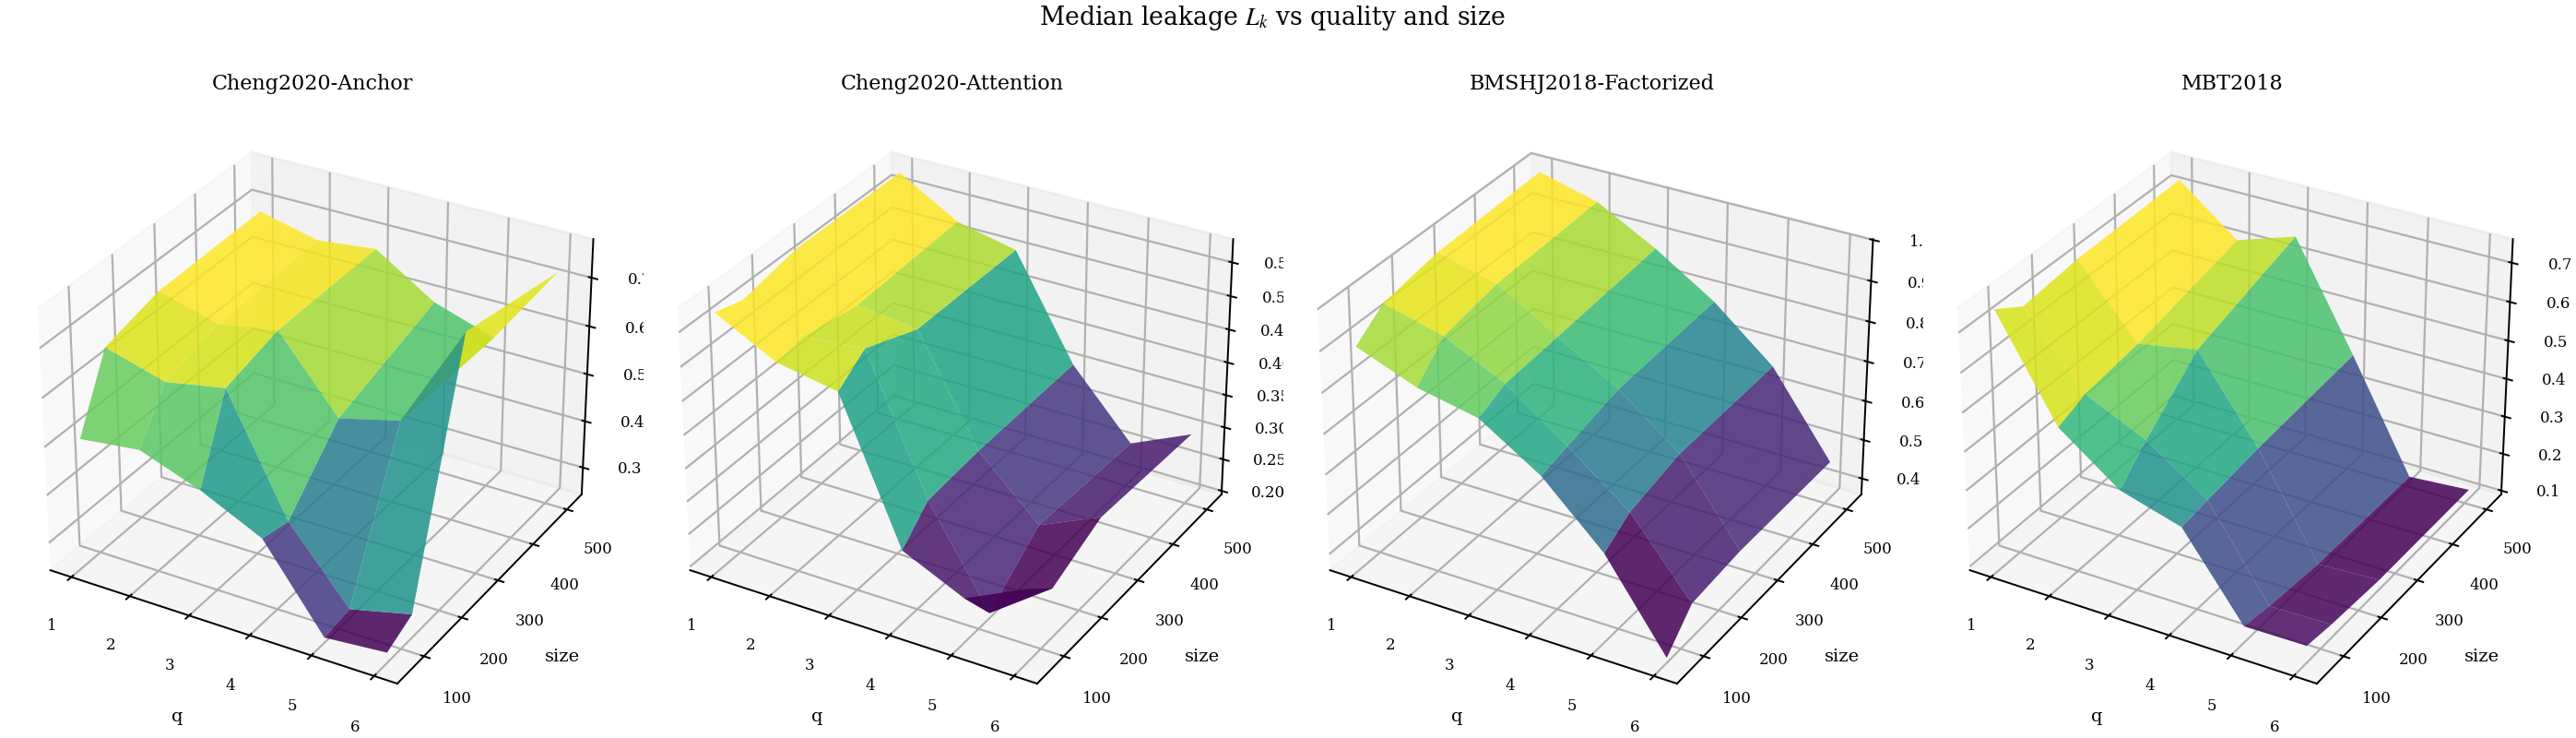

In [15]:
METRIC = 'L_k'
MODELS_3D = ['cheng2020-anchor', 'cheng2020-attn', 'bmshj2018-factorized', 'mbt2018']
SIZES_3D = [64, 128, 256, 512]
QUALITIES_3D = [1, 2, 3, 4, 5, 6]

df_all = pd.read_csv(RESULTS / 'all_metrics_summary.csv')
fig = plt.figure(figsize=(14, 4))
for idx, model_name in enumerate(MODELS_3D):
    ax = fig.add_subplot(1, len(MODELS_3D), idx + 1, projection='3d')
    sub = df_all[df_all['Model'] == model_name]
    X, Y = np.meshgrid(QUALITIES_3D, SIZES_3D)
    Z = np.full_like(X, np.nan, dtype=float)
    for qi, q in enumerate(QUALITIES_3D):
        for si, sz in enumerate(SIZES_3D):
            row = sub[(sub['q'] == q) & (sub['Size'] == f'{sz}x{sz}')]
            if not row.empty and METRIC in row.columns:
                Z[si, qi] = float(row[METRIC].iloc[0])
    mask = ~np.isnan(Z)
    if mask.any():
        ax.plot_surface(X, Y, Z, cmap=cm.viridis, alpha=0.85, linewidth=0)
    ax.set_xlabel('q', fontsize=7)
    ax.set_ylabel('size', fontsize=7)
    ax.set_zlabel(METRIC, fontsize=7)
    ax.set_title(LABEL_TEXT.get(model_name, model_name).replace('\n', '\n'), fontsize=8)
    ax.tick_params(labelsize=6)

plt.suptitle(f'Median leakage $L_k$ vs quality and size', y=1.02)
plt.tight_layout()
plt.show()

## 8. Spectral Leakage Coupling on Natural Images

The spectral leakage coupling $\tilde{\mathcal{L}}$ links the codec's DCT-domain leakage profile to distortion on real images (Table I in the paper).

In [ ]:
kodak_csv = RESULTS / 'kodak_eval' / 'kodak_per_image.csv'
if kodak_csv.exists():
    df_kodak = pd.read_csv(kodak_csv)
    clean = df_kodak[df_kodak['distortion'] == 'codec_clean']
    agg = clean.groupby('model').agg(
        mean_psnr=('psnr', 'mean'),
        mean_Le=('Le', 'mean'),
        mean_rho_bar=('rho_bar', 'mean'),
    ).round(4)
    print('Spectral leakage coupling on 24 Kodak images (codec_clean, q=6):')
    print(agg.sort_values('mean_Le', ascending=False).to_string())
else:
    print('Pre-computed Kodak results not found.')
    print('Generate: python scripts/run_kodak_eval.py --kodak-dir data/kodak')
    print('\nManual example:')
    print('   from dct_nic import spectral_leakage_coupling, evaluate_codec')
    print('   res = evaluate_codec(model, size=512)')
    print('   sc = spectral_leakage_coupling(orig_gray, recon_gray, res["leakage"])')
    print('   print(sc["L_tilde"], sc["ratio"])')

Spectral leakage coupling on 24 Kodak images (codec_clean, q=6):
                      mean_psnr  mean_Le  mean_rho_bar
model                                                 
bmshj2018-factorized    35.3808   0.1873        0.1985
cheng2020-attn          36.6765   0.1572        0.1710
cheng2020-anchor        36.7608   0.1478        0.1694
mbt2018                 37.0706   0.0986        0.1581
bmshj2018-hyperprior    36.7432   0.0965        0.1648
mbt2018-mean            36.9105   0.0884        0.1609
ftic                    37.9037   0.0168        0.1403
tcm                     38.0443   0.0039        0.1367
jpeg                    42.3012   0.0000        0.1110
jpegxl                  41.0379   0.0000        0.0878
webp                    41.6598   0.0000        0.0773


In [4]:
ROOT = Path.cwd().parent if (Path.cwd().parent / "paper").exists() else Path.cwd()
SRC_DIR = ROOT / "paper" / "div2k_clic_examples"
OUT_CROP = ROOT / "paper" / "div2k_clic_examples_crop"
OUT_RECON = ROOT / "paper" / "div2k_clic_examples_reconstructed"
MODEL_NAME, Q = "cheng2020-anchor", 6
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

ImageFile.LOAD_TRUNCATED_IMAGES = True
OUT_CROP.mkdir(parents=True, exist_ok=True)
OUT_RECON.mkdir(parents=True, exist_ok=True)

def kodak_crop_size(w: int, h: int) -> tuple[int, int]:
    return (512, 768) if w >= h else (768, 512)

def center_crop(pil_img, target_h: int, target_w: int):
    w, h = pil_img.size
    left, upper = max(0, (w - target_w) // 2), max(0, (h - target_h) // 2)
    return pil_img.crop((left, upper, left + target_w, upper + target_h))

model = load_model(MODEL_NAME, quality=Q, device=DEVICE)
model.eval()

paths = sorted(p for p in SRC_DIR.iterdir() if p.suffix.lower() in EXTENSIONS)
for i, path in enumerate(paths):
    try:
        pil_img = Image.open(path).convert("RGB")
    except OSError as e:
        print(f"Skip {path.name}: {e}")
        continue

    w, h = pil_img.size
    target_h, target_w = kodak_crop_size(w, h)
    pil_img = center_crop(pil_img, target_h, target_w)

    pil_img.save(OUT_CROP / (path.stem + ".png"), format="PNG", compress_level=6)

    x = torch.from_numpy(np.array(pil_img).astype("float32") / 255.0)
    x = x.permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        x_hat = model(x)["x_hat"].clamp(0.0, 1.0)

    out_np = (x_hat.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    Image.fromarray(out_np).save(OUT_RECON / (path.stem + ".png"), format="PNG", compress_level=6)

    if (i + 1) % 1 == 0 or i == 0:
        print(f"{i + 1}/{len(paths)}")
print(f"Done. Crop: {OUT_CROP.relative_to(ROOT.parent)}, Reconstructed: {OUT_RECON.relative_to(ROOT.parent)}")

1/3
2/3
3/3
Done. Crop: dct_benchmark_nic/paper/div2k_clic_examples_crop, Reconstructed: dct_benchmark_nic/paper/div2k_clic_examples_reconstructed
